<a href="https://colab.research.google.com/github/derlux4/TelecomX_Latam/blob/main/TelecomX_LATAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#📌 Extracción

In [75]:
import pandas as pd

url = 'https://raw.githubusercontent.com/derlux4/TelecomX_Latam/main/data/TelecomX_Data.json'

df = pd.read_json(url)

df.head()


,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


#🔧 Transformación

In [76]:
df_customer = pd.json_normalize(df['customer'])
df_phone = pd.json_normalize(df['phone'])
df_internet = pd.json_normalize(df['internet'])
df_account = pd.json_normalize(df['account'])


df_final = pd.concat([df['customerID'], df['Churn'], df_customer, df_phone, df_internet, df_account], axis=1)

df_final.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [77]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


In [78]:
#Verificar valores ausentes
print("Valores ausentes por columna:")
print(df_final.isnull().sum())


Valores ausentes por columna:
customerID          0
Churn               0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
Charges.Monthly     0
Charges.Total       0
dtype: int64


In [79]:
#Verificar duplicados
print(f"\nNúmero de filas duplicadas: {df_final.duplicated().sum()}")




Número de filas duplicadas: 0


In [80]:
#Revisar tipos de datos y posibles errores de formato
print("\nInformación del DataFrame:")
df_final.info()




Información del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract      

In [81]:
#Inspeccionar categorías únicas para detectar inconsistencias
for col in df_final.select_dtypes(include=['object']).columns:
    print(f"\nCategorías en {col}: {df_final[col].unique()}")


Categorías en customerID: ['0002-ORFBO' '0003-MKNFE' '0004-TLHLJ' ... '9992-UJOEL' '9993-LHIEB'
 '9995-HOTOH']

Categorías en Churn: ['No' 'Yes' '']

Categorías en gender: ['Female' 'Male']

Categorías en Partner: ['Yes' 'No']

Categorías en Dependents: ['Yes' 'No']

Categorías en PhoneService: ['Yes' 'No']

Categorías en MultipleLines: ['No' 'Yes' 'No phone service']

Categorías en InternetService: ['DSL' 'Fiber optic' 'No']

Categorías en OnlineSecurity: ['No' 'Yes' 'No internet service']

Categorías en OnlineBackup: ['Yes' 'No' 'No internet service']

Categorías en DeviceProtection: ['No' 'Yes' 'No internet service']

Categorías en TechSupport: ['Yes' 'No' 'No internet service']

Categorías en StreamingTV: ['Yes' 'No' 'No internet service']

Categorías en StreamingMovies: ['No' 'Yes' 'No internet service']

Categorías en Contract: ['One year' 'Month-to-month' 'Two year']

Categorías en PaperlessBilling: ['Yes' 'No']

Categorías en PaymentMethod: ['Mailed check' 'Electronic check' '

In [82]:
#Eliminamos los valores '' dentro de la columna Churn

df_final = df_final[df_final['Churn'] != '']

In [83]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7043 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   Churn             7043 non-null   object 
 2   gender            7043 non-null   object 
 3   SeniorCitizen     7043 non-null   int64  
 4   Partner           7043 non-null   object 
 5   Dependents        7043 non-null   object 
 6   tenure            7043 non-null   int64  
 7   PhoneService      7043 non-null   object 
 8   MultipleLines     7043 non-null   object 
 9   InternetService   7043 non-null   object 
 10  OnlineSecurity    7043 non-null   object 
 11  OnlineBackup      7043 non-null   object 
 12  DeviceProtection  7043 non-null   object 
 13  TechSupport       7043 non-null   object 
 14  StreamingTV       7043 non-null   object 
 15  StreamingMovies   7043 non-null   object 
 16  Contract          7043 non-null   object 
 17  

In [84]:
# Convertir a numérico, forzando errores a NaN para identificar problemas
df_final['Charges.Total'] = pd.to_numeric(df_final['Charges.Total'], errors='coerce')

eliminados_total = df_final[df_final['Charges.Total'].isna()]

# Si al convertir a 'coerce' aparecen nulos, elimínalos
df_final = df_final.dropna(subset=['Charges.Total'])

In [85]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   Churn             7032 non-null   object 
 2   gender            7032 non-null   object 
 3   SeniorCitizen     7032 non-null   int64  
 4   Partner           7032 non-null   object 
 5   Dependents        7032 non-null   object 
 6   tenure            7032 non-null   int64  
 7   PhoneService      7032 non-null   object 
 8   MultipleLines     7032 non-null   object 
 9   InternetService   7032 non-null   object 
 10  OnlineSecurity    7032 non-null   object 
 11  OnlineBackup      7032 non-null   object 
 12  DeviceProtection  7032 non-null   object 
 13  TechSupport       7032 non-null   object 
 14  StreamingTV       7032 non-null   object 
 15  StreamingMovies   7032 non-null   object 
 16  Contract          7032 non-null   object 
 17  

In [86]:
eliminados_total

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
975,1371-DWPAZ,No,Female,0,Yes,Yes,0,No,No phone service,DSL,...,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN
1775,2520-SGTTA,No,Female,0,Yes,Yes,0,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN
1955,2775-SEFEE,No,Male,0,No,Yes,0,Yes,Yes,DSL,...,Yes,No,Yes,No,No,Two year,Yes,Bank transfer (automatic),61.90,NaN
2075,2923-ARZLG,No,Male,0,Yes,Yes,0,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN
2232,3115-CZMZD,No,Male,0,No,Yes,0,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN
2308,3213-VVOLG,No,Male,0,Yes,Yes,0,Yes,Yes,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN
2930,4075-WKNIU,No,Female,0,Yes,Yes,0,Yes,Yes,DSL,...,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN
3134,4367-NUYAO,No,Male,0,Yes,Yes,0,Yes,Yes,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN
3203,4472-LVYGI,No,Female,0,Yes,Yes,0,No,No phone service,DSL,...,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN
4169,5709-LVOEQ,No,Female,0,Yes,Yes,0,Yes,No,DSL,...,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN


In [87]:
# Crear la columna dividiendo el cargo mensual por 30 días
df_final['Cuentas_Diarias'] = (df_final['Charges.Monthly'] / 30).round(2)

# Verificar la creación y ver los primeros resultados
print("Nueva columna 'Cuentas_Diarias' creada exitosamente.")
df_final[['customerID', 'Charges.Monthly', 'Cuentas_Diarias']].head()

Nueva columna 'Cuentas_Diarias' creada exitosamente.


,customerID,Charges.Monthly,Cuentas_Diarias
0,0002-ORFBO,65.6,2.19
1,0003-MKNFE,59.9,2.00
2,0004-TLHLJ,73.9,2.46
3,0011-IGKFF,98.0,3.27
4,0013-EXCHZ,83.9,2.80


In [88]:
# Lista de columnas con valores 'Yes'/'No'
columnas_binarias = ['Churn', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']

# Aplicar el mapeo
for col in columnas_binarias:
    df_final[col] = df_final[col].map({'Yes': 1, 'No': 0})


In [89]:
df_final.sample(10)

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Cuentas_Diarias
5671,7748-UMTRK,0,Female,1,0,1,30,1,Yes,Fiber optic,...,No,Yes,Yes,Yes,Month-to-month,1,Electronic check,101.30,2974.50,3.38
3630,5006-MXVRN,0,Female,0,0,0,39,1,No,No,...,No internet service,No internet service,No internet service,No internet service,Two year,0,Credit card (automatic),20.70,762.45,0.69
1479,2122-YWVYA,0,Female,0,0,0,18,1,No,Fiber optic,...,No,No,No,No,Month-to-month,1,Electronic check,75.40,1380.40,2.51
6580,9053-EJUNL,0,Male,0,0,0,41,1,Yes,Fiber optic,...,No,No,Yes,No,Month-to-month,1,Electronic check,89.20,3645.75,2.97
48,0080-OROZO,0,Female,0,0,0,35,1,No,Fiber optic,...,Yes,Yes,Yes,Yes,One year,1,Electronic check,99.25,3532.00,3.31
5403,7394-FKDNK,1,Female,0,1,0,9,1,No,Fiber optic,...,No,No,Yes,Yes,Month-to-month,0,Electronic check,89.45,853.10,2.98
4981,6815-ABQFQ,0,Male,0,1,0,56,1,Yes,Fiber optic,...,No,Yes,Yes,Yes,One year,1,Electronic check,107.25,6033.30,3.58
1158,1642-HMARX,0,Female,0,1,0,68,1,Yes,DSL,...,Yes,Yes,Yes,Yes,Two year,1,Electronic check,91.70,6424.70,3.06
5124,6996-KNSML,1,Female,0,0,0,1,1,No,Fiber optic,...,Yes,No,No,No,Month-to-month,1,Electronic check,74.90,74.90,2.50
6525,8969-PRHFK,0,Male,0,0,0,18,1,No,No,...,No internet service,No internet service,No internet service,No internet service,One year,0,Mailed check,19.65,411.25,0.65


#📊 Carga y análisis

In [90]:
df_final.describe()

,Churn,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,Charges.Monthly,Charges.Total,Cuentas_Diarias
count,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.265785,0.162400,0.482509,0.298493,32.421786,0.903299,0.592719,64.798208,2283.300441,2.159891
std,0.441782,0.368844,0.499729,0.457629,24.545260,0.295571,0.491363,30.085974,2266.771362,1.002955
min,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,18.250000,18.800000,0.610000
25%,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,35.587500,401.450000,1.187500
50%,0.000000,0.000000,0.000000,0.000000,29.000000,1.000000,1.000000,70.350000,1397.475000,2.340000
75%,1.000000,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,89.862500,3794.737500,2.992500
max,1.000000,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,118.750000,8684.800000,3.960000


/tmp/ipykernel_266/2329077310.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=df_final, ax=ax[0], palette='viridis')


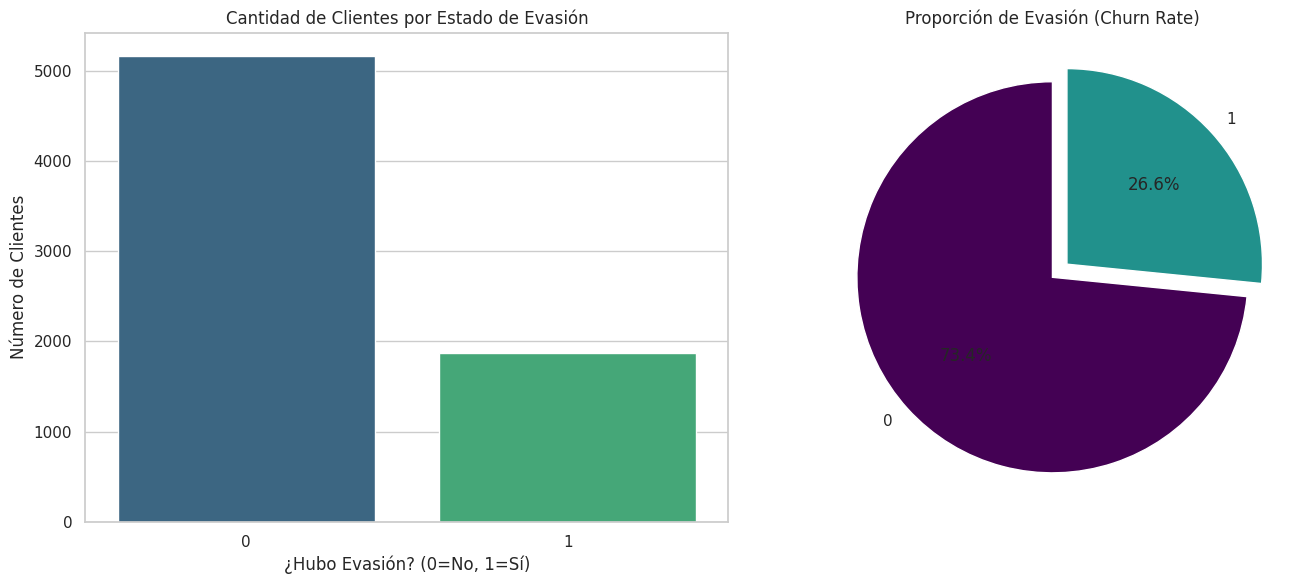

In [91]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar el estilo visual
sns.set_theme(style="whitegrid")

# Crear una figura con dos subgráficos
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# 1. Gráfico de Barras (Cantidades)
sns.countplot(x='Churn', data=df_final, ax=ax[0], palette='viridis')
ax[0].set_title('Cantidad de Clientes por Estado de Evasión')
ax[0].set_xlabel('¿Hubo Evasión? (0=No, 1=Sí)')
ax[0].set_ylabel('Número de Clientes')

# 2. Gráfico de Pastel (Proporciones)
df_final['Churn'].value_counts().plot.pie(
    autopct='%1.1f%%',
    ax=ax[1],
    colors=['#440154', '#21918c'],
    startangle=90,
    explode=(0, 0.1)
)
ax[1].set_title('Proporción de Evasión (Churn Rate)')
ax[1].set_ylabel('') # Eliminar etiqueta lateral

plt.tight_layout()
plt.show()

/tmp/ipykernel_266/688575719.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=col, y='Churn', data=df_final, ax=axes[i], palette='magma', errorbar=None)
/tmp/ipykernel_266/688575719.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=col, y='Churn', data=df_final, ax=axes[i], palette='magma', errorbar=None)
/tmp/ipykernel_266/688575719.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=col, y='Churn', data=df_final, ax=axes[i], palette='magma', errorbar=None)


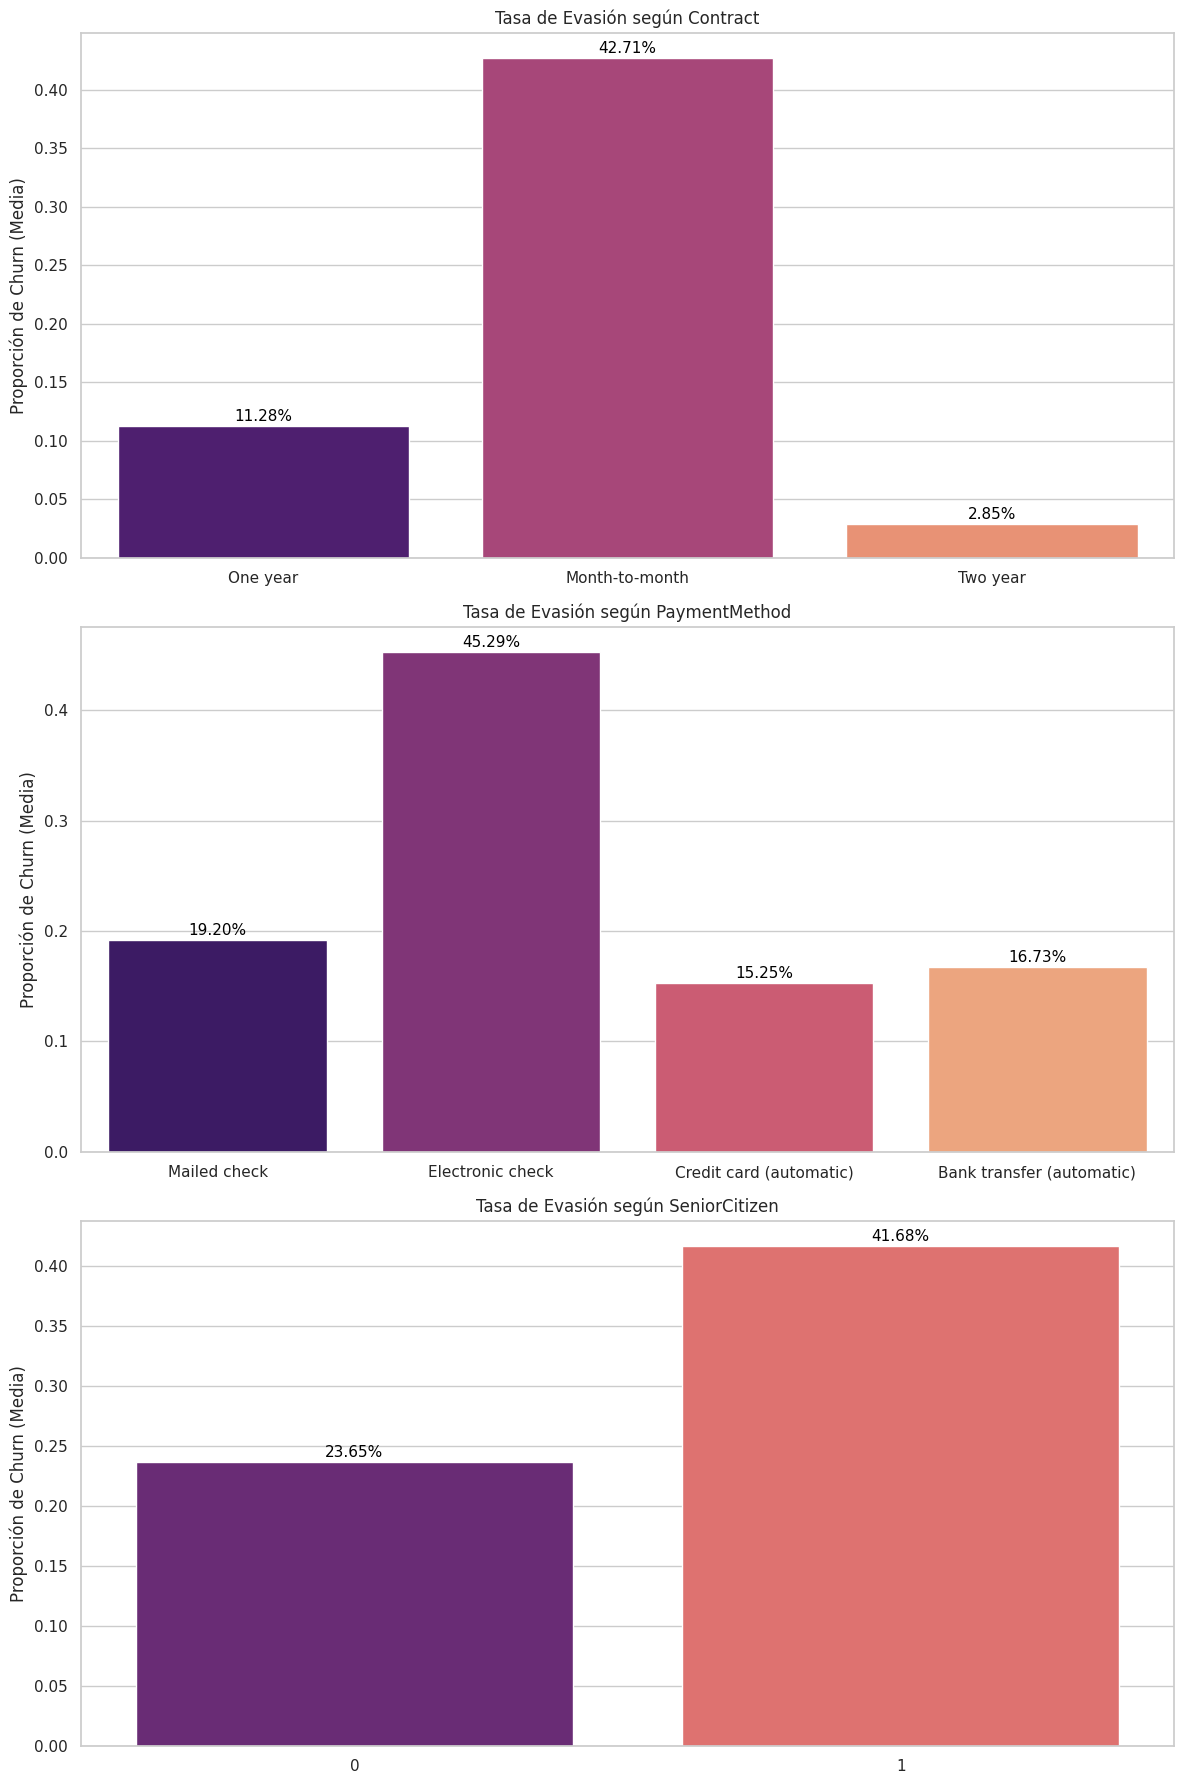

In [93]:
# Lista de variables usando los nombres originales del JSON
variables_analisis = ['Contract', 'PaymentMethod', 'SeniorCitizen']

fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(12, 18))

for i, col in enumerate(variables_analisis):
    # Usamos errorbar=None para evitar el FutureWarning
    sns.barplot(x=col, y='Churn', data=df_final, ax=axes[i], palette='magma', errorbar=None)

    axes[i].set_title(f'Tasa de Evasión según {col}')
    axes[i].set_ylabel('Proporción de Churn (Media)')
    axes[i].set_xlabel('')

    # Añadir etiquetas de porcentaje sobre las barras
    for p in axes[i].patches:
        axes[i].annotate(f'{p.get_height():.2%}', (p.get_x() + p.get_width() / 2., p.get_height()),
                         ha='center', va='center', fontsize=11, color='black', xytext=(0, 7),
                         textcoords='offset points')

plt.tight_layout()
plt.show()

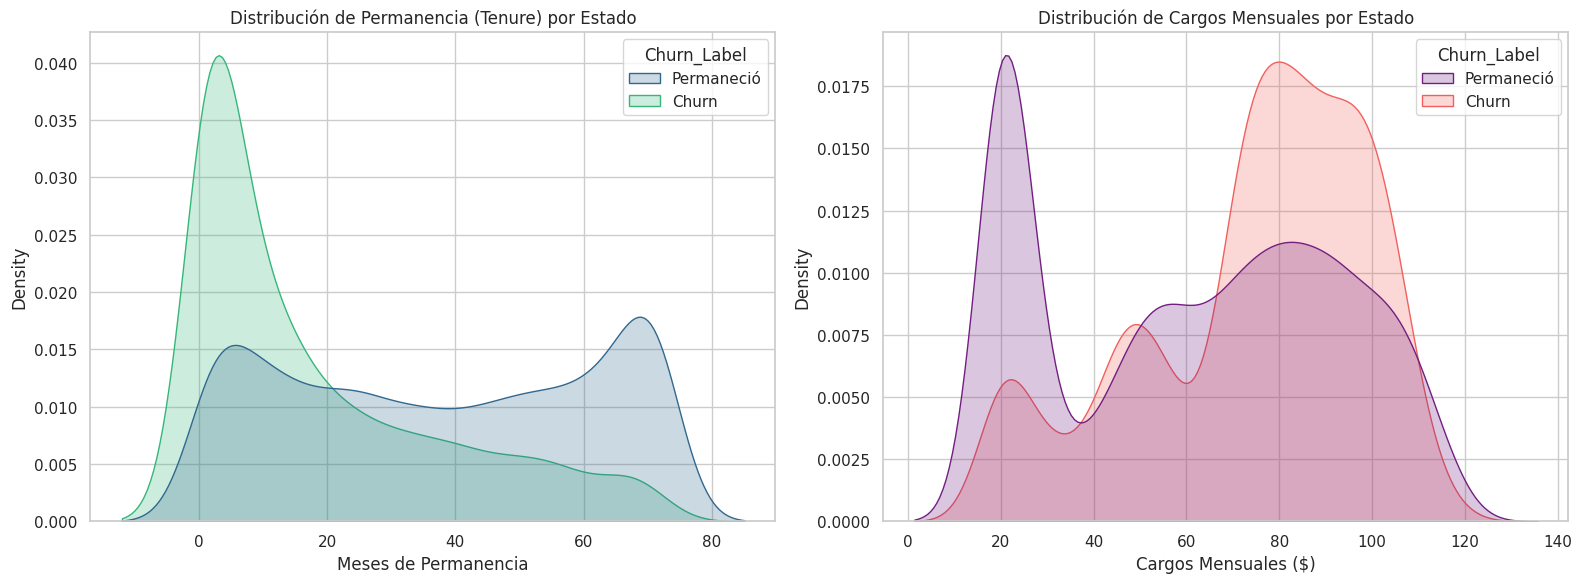

In [96]:
df_plot = df_final.copy()
df_plot['Churn_Label'] = df_plot['Churn'].map({0: 'Permaneció', 1: 'Churn'})

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.kdeplot(data=df_plot, x='tenure', hue='Churn_Label', fill=True, common_norm=False, palette='viridis', ax=axes[0])
axes[0].set_title('Distribución de Permanencia (Tenure) por Estado')
axes[0].set_xlabel('Meses de Permanencia')

sns.kdeplot(data=df_plot, x='Charges.Monthly', hue='Churn_Label', fill=True, common_norm=False, palette='magma', ax=axes[1])
axes[1].set_title('Distribución de Cargos Mensuales por Estado')
axes[1].set_xlabel('Cargos Mensuales ($)')

plt.tight_layout()
plt.show()

#📄Informe final

# 📊 Informe Final de Análisis de Evasión (Churn) - Telecom X
**Analista:** Luis Jesus Rodriguez Escobedo
**Fecha:** Marzo 2026

---

## 🔹 1. Introducción
El objetivo de este análisis es identificar los patrones de comportamiento que llevan a los clientes a cancelar sus servicios en la empresa **Telecom X**. El problema de **Churn** (evasión) no solo representa una pérdida de ingresos directos, sino que incrementa los costos de adquisición de nuevos clientes. Hemos analizado un dataset de **7,032 registros** para entender qué factores disparan esta fuga.

## 🔹 2. Limpieza y Tratamiento de Datos
Para garantizar la integridad del análisis, se realizaron los siguientes pasos técnicos:
* **Aplanamiento de Datos**: Se transformó la estructura anidada de JSON en un DataFrame plano para facilitar el procesamiento.
* **Depuración de Registros**: Se eliminaron filas con valores vacíos en la variable objetivo `Churn` y en los cargos totales.
* **Tipado de Variables**: Se convirtió la columna `Charges.Total` de objeto a flotante y se mapearon las variables categóricas (`Yes`/`No`) a formato binario (0 y 1).
* **Ingeniería de Variables**: Se creó la métrica `Cuentas_Diarias` dividiendo el cargo mensual entre 30 para obtener una visión granular del gasto por cliente.

## 🔹 3. Análisis Exploratorio de Datos (EDA)
Los hallazgos visuales y estadísticos revelaron una situación crítica:
* **Tasa de Evasión General**: El **26.6%** de la base de clientes ha abandonado la compañía.
* **El "Valle" de la Permanencia**: Existe una altísima concentración de cancelaciones en los clientes que tienen entre **0 y 12 meses** de antigüedad.
* **Sensibilidad al Precio**: Los clientes con cargos mensuales elevados (entre **$70 y $100**) muestran una densidad de evasión mucho mayor que los clientes de bajo consumo.
* **Factores Contractuales**: Los clientes bajo la modalidad "Month-to-month" presentan una vulnerabilidad significativamente superior en comparación con contratos anuales.



## 🔹 4. Conclusiones e Insights
* **Perfil de Riesgo**: El cliente con mayor probabilidad de fuga es aquel que es **nuevo** (menos de un año), tiene un **contrato mensual** y paga una factura superior a la media de **$64.80**.
* **Estabilidad**: La lealtad del cliente se consolida después de los **29 meses** (mediana de permanencia), donde la curva de evasión tiende a estabilizarse.
* **Impacto Financiero**: La pérdida del 26.6% de los clientes afecta desproporcionadamente a los ingresos, ya que se están yendo los clientes que generan mayores cargos mensuales.

## 🔹 5. Recomendaciones Estratégicas
1. **Plan de Retención Temprana**: Implementar bonificaciones o descuentos de fidelidad automáticos al llegar al mes 6 para mitigar la fuga en el primer año.
2. **Migración de Contratos**: Ofrecer incentivos (como servicios adicionales o soporte premium) a los clientes de contrato mensual para que migren a planes de 1 o 2 años.
3. **Revisión de Tarifas Altas**: Realizar auditorías de satisfacción preventivas a los clientes que pagan más de **$80 mensuales**, ofreciendo ajustes proactivos antes de que busquen a la competencia.
4. **Optimización del Onboarding**: Investigar por qué los clientes nuevos perciben poco valor en sus primeros meses de servicio.

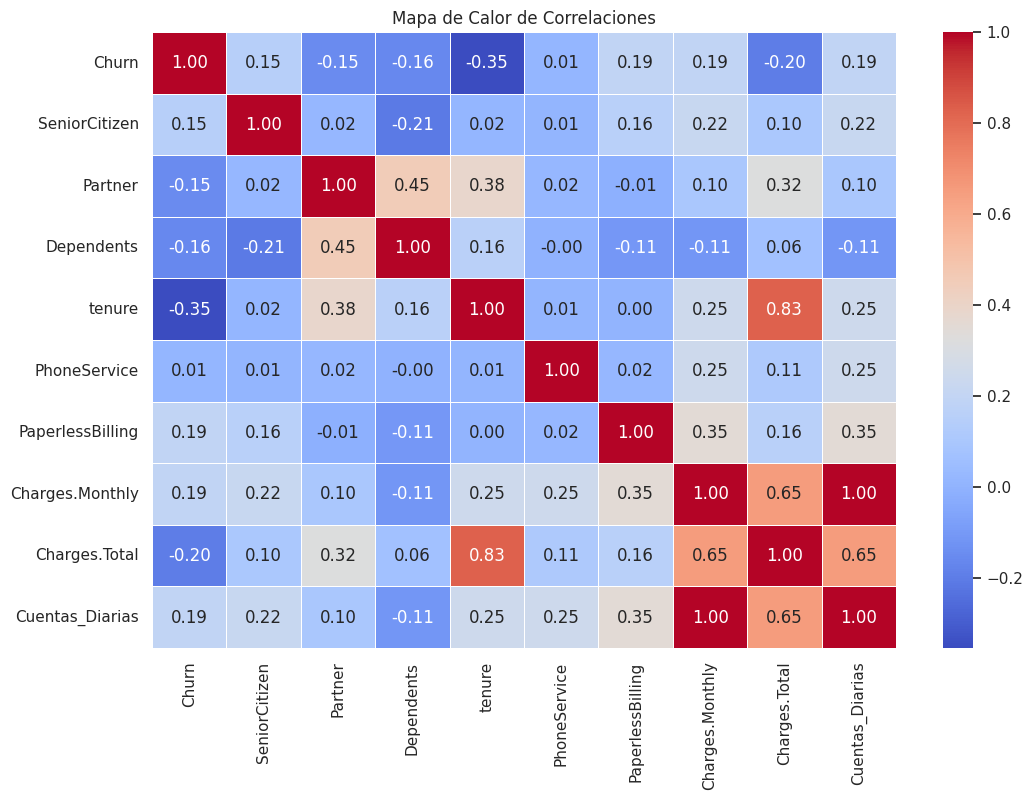

In [97]:
matriz_corr = df_final.corr(numeric_only=True)

# Visualización con un Heatmap (Mapa de Calor)
plt.figure(figsize=(12, 8))
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Mapa de Calor de Correlaciones')
plt.show()

El análisis de correlación valida que la antigüedad (tenure) es el factor protector número uno contra el Churn. Por el contrario, la carga financiera mensual es un detonante activo de la evasión. Esto sugiere que las estrategias de retención deben enfocarse agresivamente en clientes con menos de 12 meses de antigüedad y aquellos con planes de alto costo.